In [1]:
from typing import Literal

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
files = os.listdir("data/train")
data = {
    "filename": files,
    "category": [x[0:3] for x in files]
}
df = pd.DataFrame(data)
print(df["category"].value_counts())

category
dog    12500
cat    12500
Name: count, dtype: int64


In [3]:
categories = sorted(df["category"].unique())
cat2idx = {cat: i for i, cat in enumerate(categories)}
idx2cat = {v: k for k, v in cat2idx.items()}  # für später zum Decoden

df["label"] = df["category"].map(cat2idx)

print(cat2idx)

{'cat': 0, 'dog': 1}


In [4]:
df["filepath"] = df["filename"].apply(lambda x: os.path.join("data/train", x))

X = df["filepath"].values
y = df["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

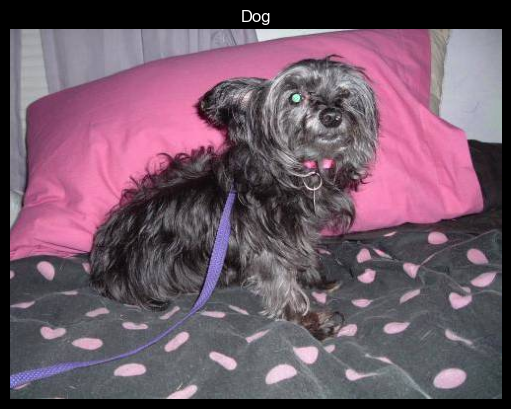

In [6]:
def show_img(category: Literal["cat", "dog"], id: int):
    img = plt.imread(f"data/train/{category}.{id}.jpg")
    plt.imshow(img)
    plt.title(category[0].upper() + category[1:])
    plt.axis('off')
    plt.show()

show_img("dog", 0)


In [7]:
num_classes = len(categories)
model_path = "modelAveragePooling.keras"
loaded = os.path.exists(model_path)

if loaded:
    print("Lade Modell")
    model = tf.keras.models.load_model(model_path)
else:
    # model = tf.keras.Sequential([
    #     tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    #     tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    #     tf.keras.layers.MaxPooling2D(2, 2),
    #     tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    #     tf.keras.layers.MaxPooling2D(2, 2),
    #     tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    #     tf.keras.layers.MaxPooling2D(2, 2),
    #     tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    #     tf.keras.layers.MaxPooling2D(2, 2),
    #
    #     tf.keras.layers.Flatten(),
    #     tf.keras.layers.Dense(512, activation='relu'),
    #     tf.keras.layers.Dropout(0.5),
    #     tf.keras.layers.Dense(num_classes, activation='softmax')
    # ])
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

In [8]:
if not loaded:
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,714 (92.63 KB)

 Trainable params: 23,714 (92.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 10

if not loaded:
    early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop]
    )

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.6023 - loss: 0.6559 - val_accuracy: 0.6692 - val_loss: 0.6148
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6701 - loss: 0.6071 - val_accuracy: 0.6896 - val_loss: 0.5882
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6921 - loss: 0.5836 - val_accuracy: 0.7222 - val_loss: 0.5669
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7068 - loss: 0.5675 - val_accuracy: 0.7320 - val_loss: 0.5560
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7199 - loss: 0.5523 - val_accuracy: 0.7114 - val_loss: 0.5746
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step - accuracy: 0.7313 - loss: 0.5391 - val_accuracy: 0.7526 - val_loss: 0.5296
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.7375 - loss: 0.5300 - val_accuracy: 0.7602 - val_loss: 0.5218
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7516 - loss: 0.5157 - 

In [11]:
def predict_image(path):
    img, _ = load_image(path, 0)
    img = tf.expand_dims(img, axis=0)
    probs = model.predict(img)[0]
    pred_idx = np.argmax(probs)
    pred_cat = idx2cat[int(pred_idx)]
    return pred_cat, probs[pred_idx]

pred_category, confidence = predict_image("data/test1/2.jpg")
print(pred_category, confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
dog 0.871152


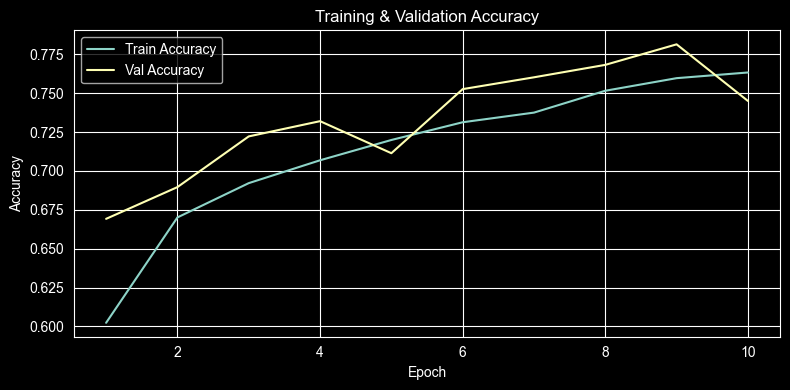

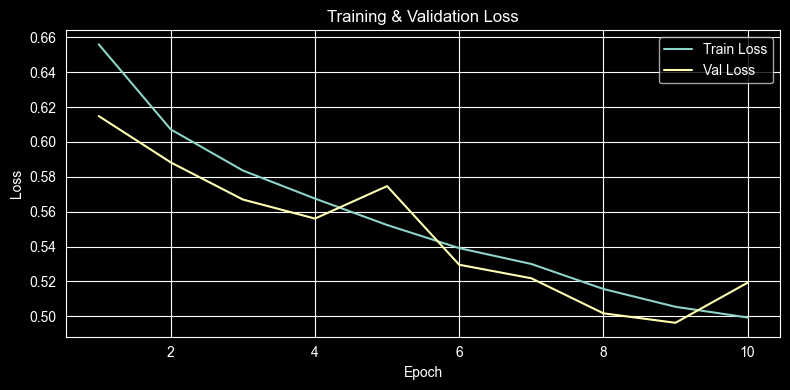

In [12]:
if not loaded:
    history_dict = history.history
    acc      = history_dict.get("accuracy", [])
    val_acc  = history_dict.get("val_accuracy", [])
    loss     = history_dict.get("loss", [])
    val_loss = history_dict.get("val_loss", [])
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
model.save(model_path)